In [1]:
# Importing Libraries
import pandas as pd
import seaborn as sns
from datasets import load_dataset
import matplotlib.pyplot as plt

# Loading Data
dataset = load_dataset('lukebarousse/data_jobs')
df = dataset['train'].to_pandas()

# Data Cleanup
df['job_posted_date'] = pd.to_datetime(df['job_posted_date'],errors="coerce")

In [3]:
df.pivot_table(index="job_title_short",aggfunc="size")

job_title_short
Business Analyst              49063
Cloud Engineer                12331
Data Analyst                 196075
Data Engineer                186241
Data Scientist               172286
Machine Learning Engineer     14080
Senior Data Analyst           29216
Senior Data Engineer          44563
Senior Data Scientist         36957
Software Engineer             44929
dtype: int64

In [7]:
df.pivot_table(
    values="salary_year_avg",
    index="job_country",
    columns="job_title_short",
    aggfunc="median"
    )

job_title_short,Business Analyst,Cloud Engineer,Data Analyst,Data Engineer,Data Scientist,Machine Learning Engineer,Senior Data Analyst,Senior Data Engineer,Senior Data Scientist,Software Engineer
job_country,,,,,,,,,,
Albania,NaN,NaN,49950.00,NaN,69981.25,NaN,NaN,NaN,157500.0,NaN
Algeria,NaN,NaN,44100.00,45000.0,NaN,NaN,NaN,NaN,NaN,NaN
Argentina,71100.0,197500.0,92771.75,96773.0,71000.00,101029.0,NaN,147500.0,NaN,174500.0
Armenia,NaN,NaN,100500.00,48750.0,NaN,87021.0,NaN,NaN,NaN,NaN
Australia,70000.0,110000.0,109500.00,106712.5,139216.00,101029.0,50640.0,147500.0,157500.0,118350.0
...,...,...,...,...,...,...,...,...,...,...
Uruguay,NaN,NaN,100500.00,NaN,NaN,50000.0,NaN,NaN,57500.0,NaN
Uzbekistan,NaN,NaN,NaN,NaN,30750.00,NaN,NaN,NaN,NaN,NaN
Vietnam,79200.0,NaN,75550.00,96773.0,70000.00,57600.0,105837.5,147500.0,79200.0,53600.0


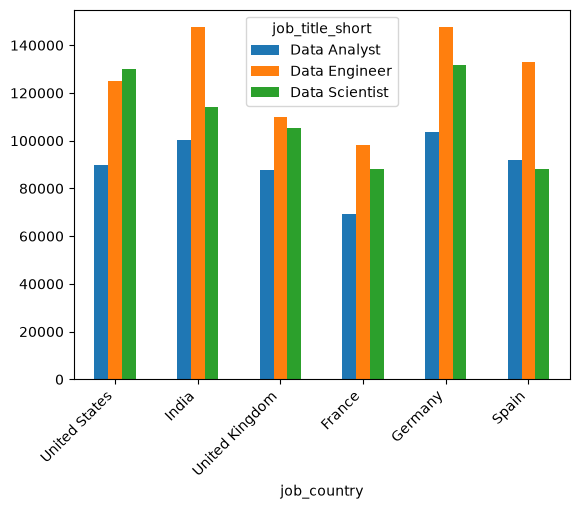

In [ ]:
top_countries = df.copy()
top_countries = top_countries["job_country"].value_counts().head(6).index

job_titles = ["Data Analyst", "Data Engineer", "Data Scientist"]

df_job_country_sal = df.copy().pivot_table(
    values="salary_year_avg",
    index="job_country",
    columns="job_title_short",
    aggfunc="median"
    )

df_job_country_sal = df_job_country_sal.loc[top_countries,job_titles]


df_job_country_sal.plot(kind="bar")
plt.xticks(rotation=45,ha="right")
plt.show()

In [32]:
df.pivot_table(values=None,index=["job_title_short","job_country"],aggfunc="size")

job_title_short    job_country
Business Analyst   Afghanistan      4
                   Albania         11
                   Algeria         21
                   Angola           1
                   Argentina      453
                                 ... 
Software Engineer  Venezuela        6
                   Vietnam        279
                   Yemen            1
                   Zambia           3
                   Zimbabwe         8
Length: 1387, dtype: int64

In [35]:
df.pivot_table(values="salary_year_avg",index="company_name",aggfunc=["max","min","mean"]).head(5)

,max,min,mean
,salary_year_avg,salary_year_avg,salary_year_avg
company_name,,,
#twiceasnice Recruiting,120000.000000,61000.000000,77750.000000
/dev/color,125000.000000,125000.000000,125000.000000
0nward Select,92500.000000,92500.000000,92500.000000
1 Point System,137290.484375,137290.484375,137290.484375
1 Point System LLC.,170000.000000,170000.000000,170000.000000


In [61]:
DataSci_Filter = (df["job_title_short"] == "Data Scientist")

pivot_df = df.copy()[DataSci_Filter].pivot_table(
    values="salary_year_avg",
    index=["company_name","job_country"],
    aggfunc="median"
)

pivot_df = pivot_df[pivot_df.values>200_000]

pivot_df.head(10)


salary_year_avg
company_name        job_country                   
ACT                 Sudan                 225000.0
                    United States         225000.0
Abbott              United States         204000.0
Airbnb              United States         212500.0
Airtable            Sudan                 215500.0
                    United States         233500.0
Algo Capital Group  Sudan                 325000.0
                    United States         350000.0
Amadeus Search      United States         232500.0
Analog Devices, Inc United States         375000.0